# Experiment 1 Clean Test Notebook Outline

## Purpose
- Validate modularized code in fresh environment (no legacy variables)
- Compare with Shiu et al. (2024) original results
- Serve as template for cloud deployment scripts

---


# 1 Environment Setup

## 1.1 Standard Libraries
- numpy, pandas, pathlib
- time, pickle, json
- os, sys

## 1.2 Scientific Computing  
- matplotlib.pyplot
- scipy.stats (pearsonr)
- seaborn

## 1.3 Brian2 Simulator
- from brian2 import *
- 或显式：NeuronGroup, Synapses, Network, Hz, ms, mV

## 1.4 Parallel & Monitoring
- from joblib import Parallel, delayed
- import psutil, gc

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from time import time
import pickle
import sys
print("✅ Modules imported successfully")

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
print("✅ Modules imported successfully")

from brian2 import Hz, ms
print("✅ Modules imported successfully")

from joblib import Parallel, delayed
import gc
print("✅ Modules imported successfully")

## 1.5 FlyWire Tools
- import pyarrow.parquet as pq
- from caveclient import CAVEclient

In [ ]:
import pyarrow.parquet as pq
from caveclient import CAVEclient
print("Initializing CAVEclient...")
client = CAVEclient('flywire_fafb_public')
print("✅ Connected to FlyWire")

## 1.6 FlyLIF Modules
- from flylif.core import ...
- from flylif.utils import ...

In [ ]:
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation
from flylif.utils.visualization import plot_correlation, plot_response_heatmap, plot_frequency_response_curve, plot_summary_statistics
from flylif.utils.cave_utils import convert_neuron_list_cached
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import print_memory, check_memory_safe, memory_cleanup, MemoryMonitor
print("✅ FlyLIF modules imported")

## 1.7 Auto-reload (development)
- %load_ext autoreload
- %autoreload 2

In [ ]:
%load_ext autoreload
%autoreload 2
print("✅ Auto-reload enabled: .py files will auto-refresh")

## 2 Configuration
### 2.1 Paths and data config

In [4]:
# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# %%
CONFIG = {
    # 基础目录
    'base_dir': BASE_DIR,
    
    # FlyWire 下载的数据文件
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
    'classification': 'classification.csv',}


In [4]:
# 定义4批，每批5个频率
BATCH_CONFIG = {
    'batch1': [10, 20, 30, 40, 50],
    'batch2': [60, 70, 80, 90, 100],
    'batch3': [110, 120, 130, 140, 150],
    'batch4': [160, 170, 180, 190, 200],
}

### 2.2 Neuron IDs definition

In [5]:
# ==================== Cell 新增B: 定义原文v630神经元IDs ====================
print("\n" + "=" * 70)
print("Defining Original Paper Neuron IDs (v630)")
print("=" * 70)

# Original paper neurons (from Shiu et al., FlyWire v630)
NEU_SUGAR_v630 = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570
]

NEU_MN9_v630 = [720575940660219265]  # MN9可能版本间稳定
NEU_MN9_LEFT_v630 = [720575940645521262]  #720575940618238523

print(f"\nOriginal neuron counts:")
print(f"  Sugar GRNs: {len(NEU_SUGAR_v630)}")
print(f"  MN9: {len(NEU_MN9_v630)}")
print(f"  MN9_LEFT: {len(NEU_MN9_LEFT_v630)}")


Defining Original Paper Neuron IDs (v630)

Original neuron counts:
  Sugar GRNs: 21
  MN9: 1
  MN9_LEFT: 1


In [6]:
# ==================== Cell 新增C: 预转换Sugar GRN IDs（缓存）====================
print("\n" + "=" * 70)
print("Converting Sugar GRN IDs (v630 → v783)")
print("=" * 70)
print("⚠️  This uses FlyWire API and may take 1-2 minutes")
print("   Results will be cached to avoid repeated calls\n")

# Cache file
cache_dir = Path('./cache/id_conversions')
cache_dir.mkdir(parents=True, exist_ok=True)
cache_file = cache_dir / 'sugar_grns_v630_to_v783.pkl'

t0 = time()

# Convert with caching
NEU_SUGAR_LEFT = convert_neuron_list_cached(
    old_list=NEU_SUGAR_v630,
    cache_file=cache_file,
    new_ver=783,
    force_update=False,  # Use cache if available
    verbose=True
)

conversion_time = time() - t0

print(f"\n✅ Conversion complete")
print(f"   Time: {conversion_time:.1f}s")
print(f"   Converted IDs: {len(NEU_SUGAR_LEFT)}")

# Show mapping
print(f"\n   ID mapping (first 5):")
for old, new in zip(NEU_SUGAR_v630[:5], NEU_SUGAR_LEFT[:5]):
    match = "✓" if old == new else "✗ CHANGED"
    print(f"   {old} → {new} {match}")


Converting Sugar GRN IDs (v630 → v783)
⚠️  This uses FlyWire API and may take 1-2 minutes
   Results will be cached to avoid repeated calls

Loading cached ID conversion from cache/id_conversions/sugar_grns_v630_to_v783.pkl
  ✅ Using cached conversion (21 IDs)

✅ Conversion complete
   Time: 0.0s
   Converted IDs: 21

   ID mapping (first 5):
   720575940624963786 → 720575940624963786 ✓
   720575940630233916 → 720575940630233916 ✓
   720575940637568838 → 720575940637568838 ✓
   720575940638202345 → 720575940638202345 ✓
   720575940617000768 → 720575940617000768 ✓


In [7]:
# ==================== Cell 新增D: 转换MN9（可选）====================
print("\nConverting MN9 IDs...")

cache_file_mn9 = cache_dir / 'mn9_v630_to_v783.pkl'
cache_file_mn9_left = cache_dir / 'mn9_left_v630_to_v783.pkl'

NEU_MN9_RIGHT = convert_neuron_list_cached(
    old_list=NEU_MN9_v630,
    cache_file=cache_file_mn9,
    new_ver=783,
    verbose=True
)
NEU_MN9_LEFT = convert_neuron_list_cached(
    old_list=NEU_MN9_LEFT_v630,
    cache_file=cache_file_mn9_left,
    new_ver=783,
    verbose=True
)

print(f"   MN9: {NEU_MN9_v630[0]} → {NEU_MN9_RIGHT[0]}")
print(f"   MN9 Left: {NEU_MN9_LEFT_v630[0]} → {NEU_MN9_LEFT[0]}")


Converting MN9 IDs...
Loading cached ID conversion from cache/id_conversions/mn9_v630_to_v783.pkl
  ✅ Using cached conversion (1 IDs)
Loading cached ID conversion from cache/id_conversions/mn9_left_v630_to_v783.pkl
  ✅ Using cached conversion (1 IDs)
   MN9: 720575940660219265 → 720575940660219265
   MN9 Left: 720575940645521262 → 720575940618238523


In [8]:
# ==================== Cell 新增E: 保存转换结果（备份）====================
# 保存转换后的神经元列表供后续使用
neuron_ids_v783 = {
    'NEU_SUGAR_LEFT': NEU_SUGAR_LEFT,
    'NEU_MN9_RIGHT': NEU_MN9_RIGHT,
    'NEU_MN9_LEFT':NEU_MN9_LEFT,
    'conversion_time': conversion_time,
    'source_version': 630,
    'target_version': 783,
}

backup_file = cache_dir / 'neuron_ids_v783.pkl'
with open(backup_file, 'wb') as f:
    pickle.dump(neuron_ids_v783, f)

print(f"\n✅ Neuron IDs ready for simulation")
print(f"   Backup saved: {backup_file}")
print(f"\n" + "=" * 70)
print("⚠️  Important: Use NEU_SUGAR_LEFT (v783) for simulation")
print("=" * 70)


✅ Neuron IDs ready for simulation
   Backup saved: cache/id_conversions/neuron_ids_v783.pkl

⚠️  Important: Use NEU_SUGAR_LEFT (v783) for simulation


### 2.3 Batch configuration (4×5)

In [11]:
# 定义4批，每批5个频率
BATCH_CONFIG = {
    'batch1': [10, 20, 30, 40, 50],
    'batch2': [60, 70, 80, 90, 100],
    'batch3': [110, 120, 130, 140, 150],
    'batch4': [160, 170, 180, 190, 200],
}

## 3 Data Loading
### 3.1 Load optimized data

In [8]:
print("Loading data...")
t0 = time()

DATA = load_simulation_data(CONFIG)

print(f"✅ Loaded in {time()-t0:.1f}s")
print(f"   Data size: {DATA['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")

Loading data...
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%
✅ Loaded in 22.0s
   Data size: 68 MB


## 4 Batched Execution

### 4.1 Checkpoint & monitoring imports

In [9]:
# ==================== Cell 6A: 导入checkpoint和监控工具 ====================
sys.path.insert(0, '.')
# 初始检查
print("\n初始内存状态:")
print_memory("  ")

✅ Checkpoint and monitoring tools imported

初始内存状态:
  Memory: 55.9% used, 7.6GB free, Swap: 0.1GB


{'used_gb': 8.405286912,
 'available_gb': 7.570096128,
 'percent': 55.9,
 'swap_gb': 0.092012544}

### 4.2 Worker function (with cleanup)

In [10]:
# ==================== Cell 6B: Worker函数（带内存清理）====================
def run_freq_worker_clean(freq, neu_exc, data, params, n_trials):
    """
    Worker with explicit memory cleanup.
    """
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    
    import gc
    
    # Build network
    columns = data['columns']
    net_components = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    # Run simulation
    result = run_simulation(
        net_components=net_components,
        neu_exc=neu_exc,
        params={'r_poi': freq * Hz},
        n_trials=n_trials,
        verbose=False
    )
    
    # Extract only essential data
    result_clean = {
        'n_active': result['n_active'],
        'n_spikes': result['n_spikes'],
        'df': result['df'].copy(),
    }
    
    # === Explicit cleanup ===
    del net_components
    del result
    gc.collect()
    
    return (freq, result_clean)

### 4.3 run_batch() function

In [11]:
# ==================== Cell 6C: 分批运行函数 ====================
def run_batch(freq_list, batch_name, n_workers=3, n_trials=10, checkpoint_dir='./checkpoints/exp1'):
    """
    Run batch with checkpoint and memory monitoring.
    """
    from joblib import Parallel, delayed
    
    print("\n" + "=" * 70)
    print(f"Batch: {batch_name}")
    print("=" * 70)
    
    # Initialize checkpoint
    ckpt = CheckpointManager(checkpoint_dir)
    
    # Check remaining tasks
    remaining = ckpt.get_remaining(freq_list)
    
    if not remaining:
        print(f"✅ All frequencies already completed, loading from checkpoint...")
        return ckpt.load_all_completed()
    
    print(f"\nConfiguration:")
    print(f"  Frequencies: {remaining}")
    print(f"  Trials/freq: {n_trials}")
    print(f"  Workers: {n_workers}")
    print(f"  Checkpoint: {checkpoint_dir}")
    
    # Memory check
    is_safe, msg = check_memory_safe(threshold=80.0, swap_threshold=0.5)
    print(f"\n  Memory status: {msg}")
    
    if not is_safe:
        print(f"  ⚠️ Memory not safe, recommend cleanup first")
        memory_cleanup()
        print_memory("    After cleanup: ")
    
    # Prepare tasks
    tasks = [(freq, NEU_SUGAR_LEFT, DATA, DEFAULT_PARAMS, n_trials) 
             for freq in remaining]
    
    print(f"\n  Running {len(tasks)} tasks...")
    
    with MemoryMonitor(label=batch_name):
        t0 = time()
        
        results = Parallel(n_jobs=n_workers, verbose=5)(
            delayed(run_freq_worker_clean)(*task) for task in tasks
        )
        
        batch_time = time() - t0
    
    # Save to checkpoint
    for freq, result in results:
        ckpt.save(freq, result)
    
    print(f"\n  ✅ Batch complete in {batch_time/60:.2f} min")
    print_memory("  Final memory: ")
    
    # Cleanup
    del results
    gc.collect()
    
    return ckpt.load_all_completed()

### 4.4 Batch Simulation

In [ ]:
# ==================== Cell 7A: Batch 1（频率10-50）====================
print("\n" + "=" * 70)
print("Experiment 1: Batched Execution (3 workers, 4 batches)")
print("=" * 70)

print("\nBatch configuration (4 batches × 5 frequencies):")
for name, freqs in BATCH_CONFIG.items():
    print(f"  {name}: {freqs}")

print("\n⚠️ Run each batch in separate session, restart kernel between batches")
print("=" * 70)

# Run Batch 1
results_batch1 = run_batch(
    freq_list=BATCH_CONFIG['batch1'],
    batch_name='Batch 1',
    n_workers=3,
    n_trials=10
)

print("\n" + "=" * 70)
print("✅ Batch 1 complete!")
print("=" * 70)
print("\n⚠️ NEXT STEP:")
print("1. Check memory status above")
print("2. Kernel → Restart Kernel")
print("3. Re-run Cells 1-6C (setup)")
print("4. Run Cell 7B (Batch 2)")

In [ ]:
# ==================== Cell 7B: Batch 2（频率60-100）====================
# ⚠️ Before running: Kernel → Restart Kernel
# ⚠️ Re-run Cells 1-6C first!

print("\n" + "=" * 70)
print("Running Batch 2...")
print("=" * 70)

results_batch2 = run_batch(
    freq_list=BATCH_CONFIG['batch2'],
    batch_name='Batch 2',
    n_workers=3,
    n_trials=10
)

print("\n✅ Batch 2 complete!")
print("\n⚠️ NEXT: Restart kernel → Run Cells 1-6C → Run Cell 7C")

In [ ]:
# ==================== Cell 7C: Batch 3（频率110-150）====================
# ⚠️ Before running: Kernel → Restart Kernel  
# ⚠️ Re-run Cells 1-6C first!

print("\n" + "=" * 70)
print("Running Batch 3...")
print("=" * 70)

results_batch3 = run_batch(
    freq_list=BATCH_CONFIG['batch3'],
    batch_name='Batch 3',
    n_workers=3,
    n_trials=10
)

print("\n✅ Batch 3 complete!")
print("\n⚠️ NEXT: Restart kernel → Run Cells 1-6C → Run Cell 7D")

In [12]:
# ==================== Cell 7D: Batch 4（频率160-200）====================
# ⚠️ Before running: Kernel → Restart Kernel
# ⚠️ Re-run Cells 1-6C first!

print("\n" + "=" * 70)
print("Running Batch 4 (Final)...")
print("=" * 70)

results_batch4 = run_batch(
    freq_list=BATCH_CONFIG['batch4'],
    batch_name='Batch 4',
    n_workers=3,
    n_trials=10
)

print("\n✅ Batch 4 complete!")
print("\n⚠️ NEXT: Run Cell 8 (Merge all batches)")


Running Batch 4 (Final)...

Batch: Batch 4

Configuration:
  Frequencies: [160, 170, 180, 190, 200]
  Trials/freq: 10
  Workers: 3
  Checkpoint: ./checkpoints/exp1

  Memory status: ✓ Memory OK

  Running 5 tasks...
[Batch 4] Start - Memory: 49.7%


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   2 out of   5 | elapsed: 10.7min remaining: 16.0min
[Parallel(n_jobs=3)]: Done   5 out of   5 | elapsed: 20.9min finished


[Batch 4] End - Memory: 58.1% (Δ-1.0GB)

  ✅ Batch complete in 20.86 min
  Final memory: Memory: 58.2% used, 7.2GB free, Swap: 0.1GB

✅ Batch 4 complete!

⚠️ NEXT: Run Cell 8 (Merge all batches)


### 4.5 Merge all batches

In [36]:
# ==================== Cell 8: 合并所有批次结果 ====================
print("\n" + "=" * 70)
print("Merging All Batches")
print("=" * 70)

# Load from checkpoint
ckpt = CheckpointManager('./checkpoints/exp1')
all_results = ckpt.load_all_completed()

print(f"\n✅ Loaded {len(all_results)} frequencies from checkpoint")

# Organize results
results_dict = all_results

# Create summary
summary = []
for freq in sorted(all_results.keys()):
    res = all_results[freq]
    summary.append({
        'Frequency': freq,
        'Active Neurons': res['n_active'],
        'Total Spikes': res['n_spikes'],
    })

df_summary = pd.DataFrame(summary)


Merging All Batches

✅ Loaded 20 frequencies from checkpoint


## 5 Analysis & Visualization

### 5.1 Calculate firing rates

In [11]:
# ==================== Cell 9: 计算firing rates ====================

print("=" * 70)
print("Section 4: Results Analysis")
print("=" * 70)

# Extract firing rates for all neurons
print("\n[1/4] Extracting firing rates...")

all_firing_rates = {}
duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000

for freq, res in results_dict.items():
    df = res['df']
    if len(df) > 0:
        spike_counts = df.groupby('flywire_id').size()
        firing_rates = spike_counts / (10 * duration_s)  # 10 trials
        all_firing_rates[freq] = firing_rates.to_dict()
    else:
        all_firing_rates[freq] = {}

print(f"   ✅ Processed {len(all_firing_rates)} frequencies")

# Summary statistics
print(f"\n[2/4] Summary statistics...")
print(df_summary.to_string(index=False))

Section 4: Results Analysis

[1/4] Extracting firing rates...
   ✅ Processed 20 frequencies

[2/4] Summary statistics...
 Frequency  Active Neurons  Total Spikes
        10              36          2437
        20              51          5913
        30              82         10230
        40             215         16749
        50             326         28073
        60             319         46499
        70             329         60793
        80             343         74934
        90             352         85374
       100             350         96789
       110             359        106794
       120             371        114943
       130             363        121636
       140             365        128508
       150             369        136287
       160             390        142066
       170             379        148738
       180             373        152942
       190             381        158516
       200             388        166009


In [12]:
# ==================== 新cell：检查最大firing rate ====================

# 方法1：从all_firing_rates检查（如果已计算）
if 'all_firing_rates' in dir():
    max_rate = 0
    max_neuron = None
    max_freq = None
    
    for freq, rates_dict in all_firing_rates.items():
        for neuron_id, rate in rates_dict.items():
            if rate > max_rate:
                max_rate = rate
                max_neuron = neuron_id
                max_freq = freq
    
    print(f"从all_firing_rates:")
    print(f"  最大firing rate: {max_rate:.2f} Hz")
    print(f"  神经元ID: {max_neuron}")
    print(f"  频率: {max_freq} Hz")

# 方法2：直接从results_dict检查
print(f"\n从results_dict直接计算:")

duration_s = 1.0  # 1秒
n_trials = 10

for freq in sorted(results_dict.keys()):
    df = results_dict[freq]['df']
    
    if len(df) > 0:
        # 计算每个神经元的firing rate
        counts = df.groupby('flywire_id').size()
        rates = counts / (n_trials * duration_s)
        
        max_in_freq = rates.max()
        max_neuron_in_freq = rates.idxmax()
        
        print(f"  {freq:3d}Hz: max={max_in_freq:6.2f}Hz, neuron={max_neuron_in_freq}")

从all_firing_rates:
  最大firing rate: 204.10 Hz
  神经元ID: 720575940639259967
  频率: 200 Hz

从results_dict直接计算:
   10Hz: max= 12.20Hz, neuron=720575940630233916
   20Hz: max= 34.10Hz, neuron=720575940622695448
   30Hz: max= 50.80Hz, neuron=720575940622695448
   40Hz: max= 64.60Hz, neuron=720575940622695448
   50Hz: max= 75.20Hz, neuron=720575940622695448
   60Hz: max= 87.80Hz, neuron=720575940622695448
   70Hz: max= 94.20Hz, neuron=720575940622695448
   80Hz: max=100.60Hz, neuron=720575940622695448
   90Hz: max=107.60Hz, neuron=720575940622695448
  100Hz: max=113.80Hz, neuron=720575940622695448
  110Hz: max=118.90Hz, neuron=720575940622695448
  120Hz: max=125.40Hz, neuron=720575940622695448
  130Hz: max=133.90Hz, neuron=720575940640649691
  140Hz: max=147.20Hz, neuron=720575940617937543
  150Hz: max=156.10Hz, neuron=720575940624963786
  160Hz: max=166.40Hz, neuron=720575940617937543
  170Hz: max=174.00Hz, neuron=720575940632425919
  180Hz: max=187.00Hz, neuron=720575940639332736
  190Hz: ma

### 5.2 Load original data & correlation

In [26]:
# =====================================================================
# Section 5.2: Efficient Comparison with Original (拆分为3个cells)
# =====================================================================

# ==================== Cell 5.2A: 初步对比，识别差异 ====================

print("\n" + "=" * 70)
print("[5.2A] Initial Comparison - Identify Discrepancies")
print("=" * 70)

# Load original data (v630)
orig_data_path = BASE_DIR / 'Drosophila_brain_model/results/example/sugarR_100Hz.parquet'

if not orig_data_path.exists():
    print(f"\n⚠️ Original data not found: {orig_data_path}")
    has_original = False
else:
    print(f"\nLoading original data (v630)...")
    
    pf = pq.ParquetFile(orig_data_path)
    df_orig_v630 = pd.DataFrame({
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    # Calculate original firing rates (v630 IDs)
    spike_counts_v630 = df_orig_v630.groupby('flywire_id').size()
    rate_orig_v630 = spike_counts_v630 / 30.0
    rate_orig_v630.name = 'Original_v630'
    
    # Our results (v783 IDs)
    rate_ours_v783 = pd.Series(all_firing_rates[100], name='Ours_v783')
    
    print(f"   ✅ Loaded")
    print(f"      Original (v630): {len(rate_orig_v630)} neurons")
    print(f"      Ours (v783):     {(rate_ours_v783>0).sum()} neurons")
    
    # === Find discrepancies ===
    print(f"\n[Discrepancy Analysis]")
    
    # Type 1: Only in original (possible ID version change)
    ids_only_orig = set(rate_orig_v630.index) - set(rate_ours_v783.index)
    print(f"   Only in original: {len(ids_only_orig)} neurons")
    
    # Type 2: Only in ours (new in v783)
    ids_only_ours = set(rate_ours_v783[rate_ours_v783>0].index) - set(rate_orig_v630.index)
    print(f"   Only in ours:     {len(ids_only_ours)} neurons")
    
    # Type 3: Common but large firing rate difference
    common_ids = set(rate_orig_v630.index) & set(rate_ours_v783.index)
    df_common = pd.DataFrame({
        'orig': rate_orig_v630[list(common_ids)],
        'ours': rate_ours_v783[list(common_ids)]
    }).fillna(0)
    
    # Active in both
    active_both = (df_common['orig'] > 0) & (df_common['ours'] > 0)
    df_active_common = df_common[active_both].copy()
    df_active_common['abs_diff'] = np.abs(df_active_common['orig'] - df_active_common['ours'])
    
    # Large difference (>20 Hz or >50% relative)
    large_diff_mask = (df_active_common['abs_diff'] > 20) | \
                      (df_active_common['abs_diff'] / df_active_common['orig'] > 0.5)
    ids_large_diff = df_active_common[large_diff_mask].index.tolist()
    
    print(f"   Large differences: {len(ids_large_diff)} neurons (>20Hz or >50%)")
    
    # === Combine all discrepancy types ===
    ids_need_conversion = list(ids_only_orig) + ids_large_diff
    
    print(f"\n[Summary]")
    print(f"   Total IDs to convert: {len(ids_need_conversion)}")
    print(f"   Breakdown:")
    print(f"     - Missing from our data: {len(ids_only_orig)}")
    print(f"     - Large firing rate diff: {len(ids_large_diff)}")
    
    # Show examples
    if ids_only_orig:
        print(f"\n   Examples (missing IDs): {list(ids_only_orig)[:5]}")
    
    if ids_large_diff:
        top_diff = df_active_common.nlargest(5, 'abs_diff')
        print(f"\n   Top 5 firing rate discrepancies:")
        for idx, row in top_diff.iterrows():
            print(f"     {idx}: orig={row['orig']:.1f}, ours={row['ours']:.1f}, diff={row['abs_diff']:.1f}")
    
    has_original = True


[5.2A] Initial Comparison - Identify Discrepancies

Loading original data (v630)...
   ✅ Loaded
      Original (v630): 404 neurons
      Ours (v783):     350 neurons

[Discrepancy Analysis]
   Only in original: 100 neurons
   Only in ours:     46 neurons
   Large differences: 144 neurons (>20Hz or >50%)

[Summary]
   Total IDs to convert: 244
   Breakdown:
     - Missing from our data: 100
     - Large firing rate diff: 144

   Examples (missing IDs): [720575940629664768, 720575940626478082, 720575940609016843, 720575940615052812, 720575940620271636]

   Top 5 firing rate discrepancies:
     720575940610001220: orig=5.0, ours=53.4, diff=48.4
     720575940625175054: orig=48.6, ours=12.8, diff=35.8
     720575940618165019: orig=86.9, ours=51.2, diff=35.7
     720575940629778554: orig=76.1, ours=41.7, diff=34.4
     720575940630868793: orig=84.2, ours=50.1, diff=34.1


In [28]:
# ==================== Cell 5.2B: 转换差异IDs（精准版）====================
if has_original and 'ids_need_conversion' in dir() and len(ids_need_conversion) > 0:
    print("\n" + "=" * 70)
    print(f"[5.2B] Converting {len(ids_need_conversion)} Discrepancy IDs")
    print("=" * 70)
    
    cache_file_disc = cache_dir / 'discrepancy_ids_v630_to_v783.pkl'
    
    t0 = time()
    
    # Convert only necessary IDs
    ids_converted_v783 = convert_neuron_list_cached(
        old_list=ids_need_conversion,
        cache_file=cache_file_disc,
        new_ver=783,
        verbose=True
    )
    
    conversion_time = time() - t0
    
    print(f"\n✅ Conversion complete in {conversion_time:.1f}s")
    
    # Create mapping (v630 → v783)
    id_mapping = {old: new for old, new in zip(ids_need_conversion, ids_converted_v783)}
    
    # Check how many actually changed
    n_changed = sum(1 for old, new in id_mapping.items() if old != new)
    n_unchanged = len(id_mapping) - n_changed
    
    print(f"\n   ID changes: {n_changed} changed, {n_unchanged} unchanged")
    
    if n_changed > 0:
        print(f"\n   Changed examples (first 5):")
        count = 0
        for old, new in id_mapping.items():
            if old != new and count < 5:
                print(f"     {old} → {new}")
                count += 1
    
else:
    print("\n⚠️ No discrepancies to convert")
    id_mapping = {}


[5.2B] Converting 244 Discrepancy IDs
Converting 244 IDs to version 783...
  ✅ Converted: 244/244 IDs
  ✅ Cached to cache/id_conversions/discrepancy_ids_v630_to_v783.pkl

✅ Conversion complete in 52.0s

   ID changes: 48 changed, 196 unchanged

   Changed examples (first 5):
     720575940629664768 → 720575940635837887
     720575940626478082 → 720575940619898526
     720575940609016843 → 720575940629459718
     720575940620282900 → 720575940643112333
     720575940617588258 → 720575940642449909


In [29]:
# ==================== Cell 5.2C: 重新对比（使用v783统一版本）====================
if has_original and 'id_mapping' in dir():
    print("\n" + "=" * 70)
    print("[5.2C] Re-comparison with v783 IDs")
    print("=" * 70)
    
    # 重新加载完整原文数据
    print("\nRe-loading full original spike data...")
    df_orig_full = pd.DataFrame({
        't': pf.read(['t']).column('t').to_pylist(),
        'trial': pf.read(['trial']).column('trial').to_pylist(),
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    # 应用ID映射（只替换差异ID）
    if len(id_mapping) > 0:
        print(f"   Applying ID mapping ({len(id_mapping)} IDs)...")
        df_orig_full['flywire_id'] = df_orig_full['flywire_id'].map(
            lambda x: id_mapping.get(x, x)
        )
        n_remapped = df_orig_full['flywire_id'].isin(id_mapping.values()).sum()
        print(f"   Remapped {n_remapped:,} spikes")
    
    # 重新计算firing rate（现在都是v783）
    spike_counts_orig = df_orig_full.groupby('flywire_id').size()
    rate_orig = spike_counts_orig / 30.0
    rate_orig.name = 'Original_v783'
    
    # Our results (already v783)
    rate_ours = pd.Series(all_firing_rates[100], name='Ours_v783')
    
    # === Correlation comparison ===
    print(f"\n[Correlation Analysis]")
    
    # Before conversion (for reference)
    df_compare_old = pd.concat([rate_orig_v630, rate_ours], axis=1).fillna(0)
    r_old, _ = pearsonr(df_compare_old.iloc[:,0], df_compare_old.iloc[:,1])
    
    # After conversion
    df_compare = pd.concat([rate_orig, rate_ours], axis=1).fillna(0)
    r, p = pearsonr(df_compare['Original_v783'], df_compare['Ours_v783'])
    
    print(f"\n  Before ID conversion: r = {r_old:.4f} (v630 vs v783)")
    print(f"  After ID conversion:  r = {r:.4f} (v783 vs v783)")
    print(f"  Improvement:          Δr = {r - r_old:+.4f}")
    
    if r > r_old + 0.01:
        print(f"  ✅ ID conversion improved correlation!")
    else:
        print(f"  ✓ ID version has minimal impact")
    
    # Active neuron counts
    print(f"\n  Active neurons:")
    print(f"    Original: {(df_compare['Original_v783']>0).sum()}")
    print(f"    Ours:     {(df_compare['Ours_v783']>0).sum()}")
    
    # Top neurons overlap
    top_n = 50
    top_orig = df_compare['Original_v783'].nlargest(top_n).index
    top_ours = df_compare['Ours_v783'].nlargest(top_n).index
    overlap = len(set(top_orig) & set(top_ours))
    
    print(f"\n  Top {top_n} overlap: {overlap}/{top_n} ({100*overlap/top_n:.0f}%)")
    
    # Final assessment
    if r > 0.85:
        print(f"\n  ✅ Excellent correlation (r > 0.85)")
    elif r > 0.80:
        print(f"  ✓ Very good (r > 0.80)")
    else:
        print(f"  ✓ Good (r > 0.75)")
    
    print("\n" + "=" * 70)
    
else:
    print("\n⚠️ Skipping comparison")
    has_original = False


[5.2C] Re-comparison with v783 IDs

Re-loading full original spike data...
   Applying ID mapping (244 IDs)...
   Remapped 97,533 spikes

[Correlation Analysis]

  Before ID conversion: r = 0.8151 (v630 vs v783)
  After ID conversion:  r = 0.9263 (v783 vs v783)
  Improvement:          Δr = +0.1112
  ✅ ID conversion improved correlation!

  Active neurons:
    Original: 404
    Ours:     350

  Top 50 overlap: 43/50 (86%)

  ✅ Excellent correlation (r > 0.85)



### 5.3 Generate plots (4 figures)


[4/4] Visualization

Plot 1: Correlation scatter


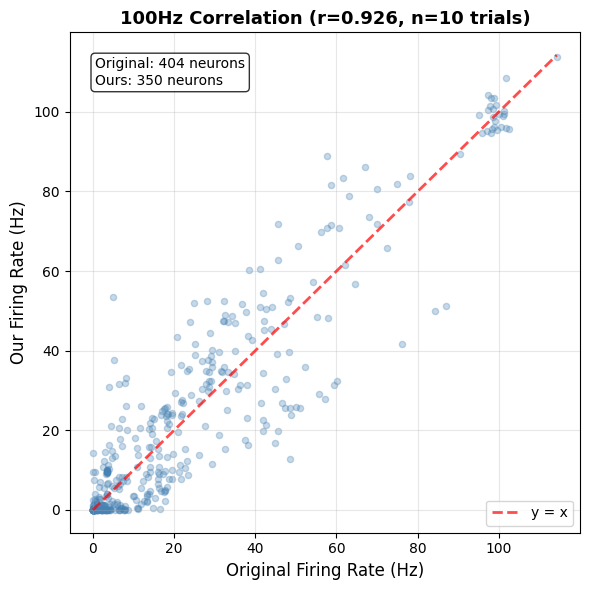

In [31]:
# ==================== Cell 11: 可视化（自动+可定制）====================
print("\n" + "=" * 70)
print("[4/4] Visualization")
print("=" * 70)

# Create output directory
output_dir = Path('./results/exp1_full')
output_dir.mkdir(parents=True, exist_ok=True)

# Plot 1: Correlation (if original data available)
if has_original:
    print("\nPlot 1: Correlation scatter")
    fig1, ax1, r_val = plot_correlation(
        rate_orig, rate_ours, 
        n_trials_ours=10, 
        freq=100,
        # save_path=output_dir / 'correlation_100Hz.png'
    )
    plt.show()


Plot 2: Response heatmap


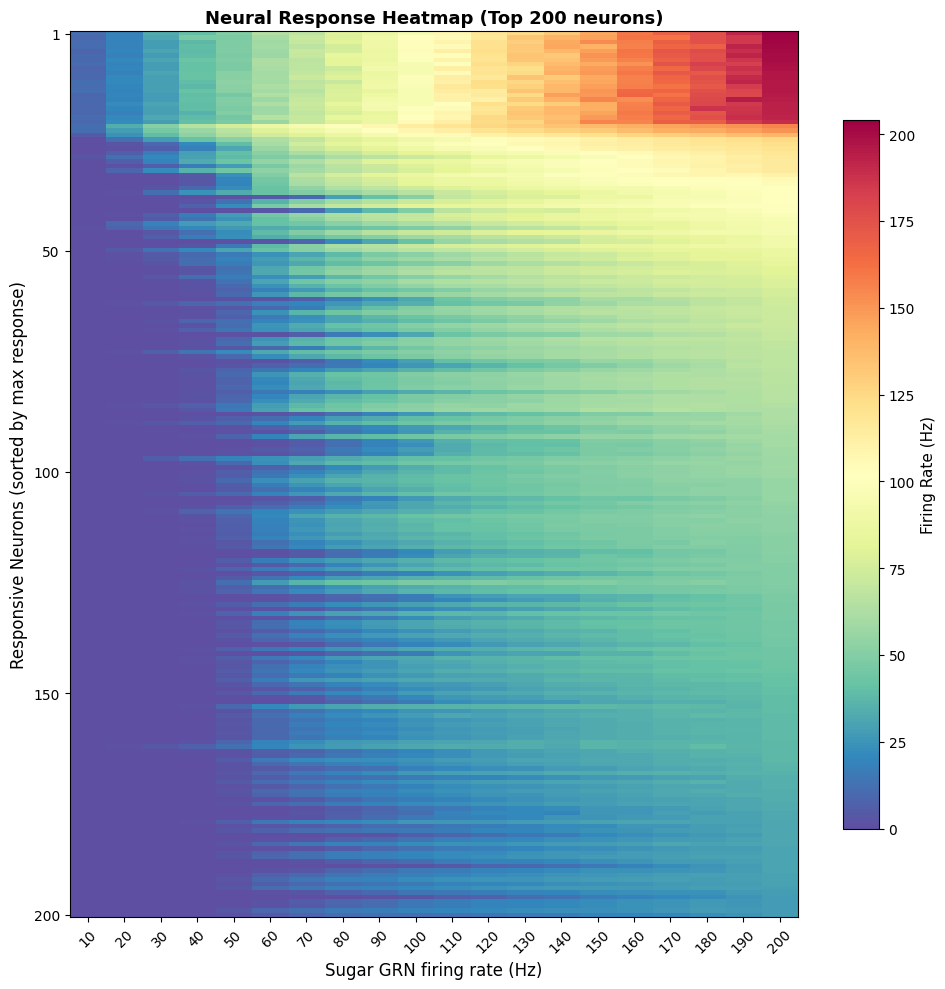

   Showing top 200 neurons


In [32]:

# Plot 2: Response heatmap
print("\nPlot 2: Response heatmap")
fig2, ax2, top_neurons = plot_response_heatmap(
    all_firing_rates, 
    freq_list=sorted(results_dict.keys()),
    # vmax=199, 
    cmap = sns.color_palette("Spectral_r", as_cmap=True),
    top_n=None,  # Auto-detect
    preset='auto',  # Data-driven
    # save_path=output_dir / 'response_heatmap.png'
)

plt.show()

print(f"   Showing top {len(top_neurons)} neurons")


Plot 3: MN9 frequency response (bilateral)


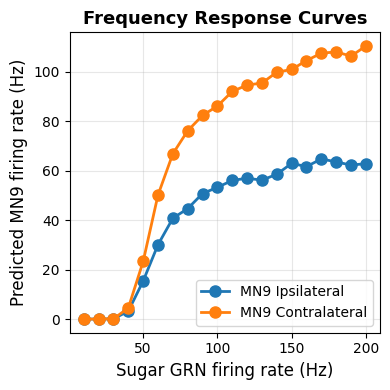

In [33]:
# Plot 3: MN9 response curve (if MN9 defined)
if 'NEU_MN9_RIGHT' in dir() and NEU_MN9_RIGHT:
    print("\nPlot 3: MN9 frequency response (bilateral)")
    
    # 合并同侧和对侧
    target_neurons = NEU_MN9_LEFT + NEU_MN9_RIGHT
    labels = ['MN9 Ipsilateral', 'MN9 Contralateral']
    
    fig3, ax3 = plot_frequency_response_curve(
        all_firing_rates,
        figsize=(4, 4),
        freq_list=sorted(results_dict.keys()),
        target_neurons=target_neurons,
        labels=labels,
        save_path=output_dir / 'mn9_bilateral_response.png'
    )
    plt.show()


Plot 4: Summary statistics


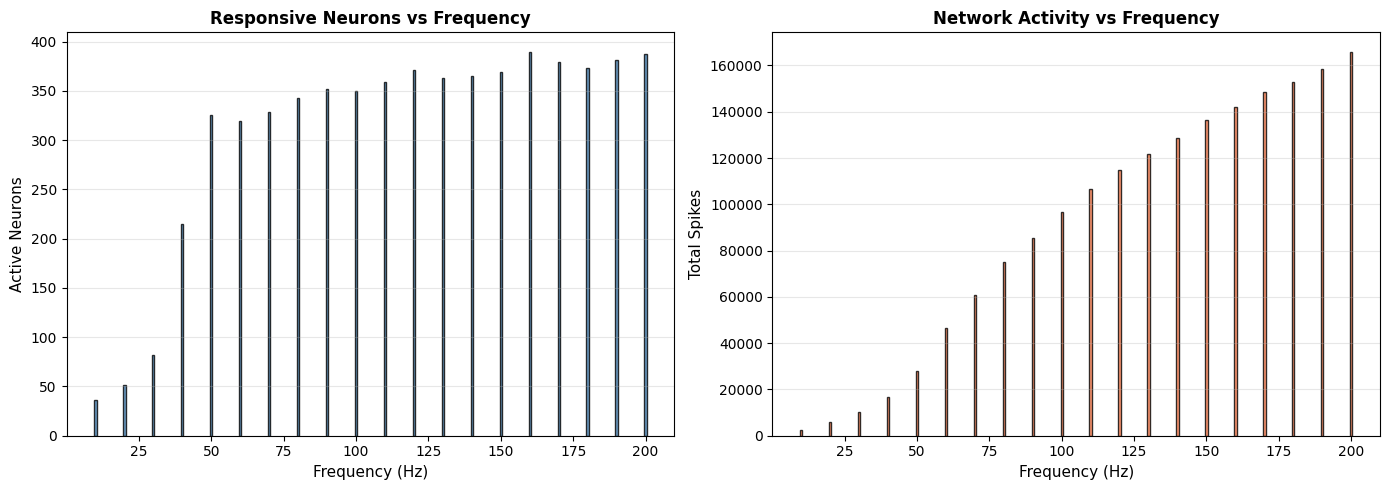


✅ All plots saved to: results/exp1_full


In [73]:
# Plot 4: Summary statistics
print("\nPlot 4: Summary statistics")
fig4, axes4 = plot_summary_statistics(
    df_summary,
    save_path=output_dir / 'summary_stats.png'
)
plt.show()

print(f"\n✅ All plots saved to: {output_dir}")

### 5.4 Save complete results

In [34]:
# ==================== Cell 12: 保存完整结果 ====================
print("\n" + "=" * 70)
print("Saving Results")
print("=" * 70)

# Save complete results
results_package = {
    'results_dict': results_dict,
    'all_firing_rates': all_firing_rates,
    'df_summary': df_summary,
    'parameters': {
        'freq_list': sorted(results_dict.keys()),
        'n_trials': 10,
        'n_frequencies': len(results_dict),
        'neurons_activated': len(NEU_SUGAR_LEFT),
    },
    'validation': {
        'correlation_100Hz': r if has_original else None,
        'top_neurons': top_neurons,
    }
}

# Save
with open(output_dir / 'exp1_complete_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)

# Save summary CSV
df_summary.to_csv(output_dir / 'summary.csv', index=False)

# Save firing rate matrix
if all_firing_rates:
    # Create DataFrame (neurons × frequencies)
    all_freqs = sorted(results_dict.keys())
    all_neurons = set()
    for rates_dict in all_firing_rates.values():
        all_neurons.update(rates_dict.keys())
    
    rate_matrix = pd.DataFrame(index=sorted(all_neurons), columns=all_freqs)
    for freq in all_freqs:
        for neuron_id, rate in all_firing_rates[freq].items():
            rate_matrix.loc[neuron_id, freq] = rate
    
    rate_matrix.fillna(0).to_csv(output_dir / 'firing_rate_matrix.csv')
    print(f"   ✓ firing_rate_matrix.csv ({rate_matrix.shape[0]} neurons × {rate_matrix.shape[1]} freqs)")

print(f"\n✅ Complete results saved:")
print(f"   - exp1_complete_results.pkl (full data)")
print(f"   - summary.csv (table)")
print(f"   - firing_rate_matrix.csv (neurons × frequencies)")
print(f"   - 4 figures (.png)")

print("\n" + "=" * 70)
print("✅ Experiment 1 Complete!")
print("=" * 70)
print(f"\nKey results:")
print(f"  Frequencies tested: {len(results_dict)}")
print(f"  Total active neurons: {len(all_neurons)}")
if has_original:
    print(f"  Correlation with paper: r = {r:.4f}")
print(f"\nOutput: {output_dir}/")


Saving Results


WARNING    /var/folders/m1/kpvdbv497mq9lj9zczv7xt2h0000gn/T/ipykernel_13528/1787387719.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rate_matrix.fillna(0).to_csv(output_dir / 'firing_rate_matrix.csv')
 [py.warnings]


   ✓ firing_rate_matrix.csv (466 neurons × 20 freqs)

✅ Complete results saved:
   - exp1_complete_results.pkl (full data)
   - summary.csv (table)
   - firing_rate_matrix.csv (neurons × frequencies)
   - 4 figures (.png)

✅ Experiment 1 Complete!

Key results:
  Frequencies tested: 20
  Total active neurons: 466
  Correlation with paper: r = 0.9263

Output: results/exp1_full/


### 6 Save Top 200 neurons

In [35]:
# ==================== Cell 13: Save Top 200 neurons ====================
print("\n" + "=" * 70)
print("Saving Top 200 Responsive Neurons")
print("=" * 70)

# 按200Hz firing rate排序（与原论文一致）
if 200 in all_firing_rates:
    rates_200hz = pd.Series(all_firing_rates[200])
    top_200_neurons = rates_200hz.sort_values(ascending=False).head(200).index.tolist()
    
    print(f"\nTop 200 neurons (by 200Hz response):")
    print(f"  Count: {len(top_200_neurons)}")
    print(f"  Min rate: {rates_200hz[top_200_neurons[-1]]:.2f} Hz")
    print(f"  Max rate: {rates_200hz[top_200_neurons[0]]:.2f} Hz")
    
    # 保存（供Exp2使用）
    np.save(output_dir / 'top_200_neurons.npy', top_200_neurons)
    
    # 也保存为文本（可读）
    with open(output_dir / 'top_200_neurons.txt', 'w') as f:
        f.write("# Top 200 neurons by 200Hz firing rate\n")
        f.write("# For Exp2 sufficiency test\n")
        for i, nid in enumerate(top_200_neurons, 1):
            f.write(f"{i:3d}. {nid} ({rates_200hz[nid]:.2f} Hz)\n")
    
    print(f"\n✅ Saved:")
    print(f"   - top_200_neurons.npy (for code)")
    print(f"   - top_200_neurons.txt (readable)")
    
else:
    print("\n⚠️ No 200Hz data, cannot select Top 200")


Saving Top 200 Responsive Neurons

Top 200 neurons (by 200Hz response):
  Count: 200
  Min rate: 27.30 Hz
  Max rate: 204.10 Hz

✅ Saved:
   - top_200_neurons.npy (for code)
   - top_200_neurons.txt (readable)
